# Задание №2. Бинарная классификация ЭКГ по параметрам волн

**Цель:** обработка кардиологического датасета, бинарная классификация по признаку `Healthy_Status`.

**Навыки:** подготовка данных, PCA и t-SNE, сравнение AutoML-фреймворков, расчёт F1 и confusion matrix.

**Датасет:** [AI-is-out-there/data2lab — модуль 3](https://github.com/AI-is-out-there/data2lab)


## 1. Загрузка данных

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

url = "https://raw.githubusercontent.com/AI-is-out-there/data2lab/refs/heads/main/%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D1%8C%203%20-%20%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%20-%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.csv"
df_full = pd.read_csv(url, nrows=5000)
print(f"Загружено строк: {len(df_full)}")
print("Столбцы:", df_full.columns.tolist())

selected_cols = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 
                 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']
df = df_full[selected_cols].copy()


Загружено строк: 5000
Столбцы: ['subject_id', 'Count_subj', 'study_id', 'cart_id', 'Healthy_Status', 'eeg_time ', 'eeg_date ', 'report_0', 'report_1', 'report_2', 'report_3', 'report_4', 'report_5', 'report_6', 'report_7', 'report_8', 'report_9', 'report_10', 'report_11', 'report_12', 'report_13', 'report_14', 'report_15', 'report_16', 'report_17', 'bandwidth', 'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis']


## 2. Очистка от аномальных значений

In [11]:
def clean_outliers(df, col, valid_range=(None, None), replace_with=np.nan):
    """
    Заменяет значения вне диапазона на NaN.
    valid_range: (min, max) – если None, то граница не проверяется.
    """
    min_val, max_val = valid_range
    if min_val is not None:
        df.loc[df[col] < min_val, col] = replace_with
    if max_val is not None:
        df.loc[df[col] > max_val, col] = replace_with
    return df

clean_outliers(df, 'rr_interval', (300, 2000))

clean_outliers(df, 'p_end', (0, 500))
clean_outliers(df, 'qrs_onset', (0, 500))
clean_outliers(df, 'qrs_end', (0, 500))

clean_outliers(df, 'p_axis', (-180, 180))
clean_outliers(df, 'qrs_axis', (-180, 180))
clean_outliers(df, 't_axis', (-180, 180))

clean_outliers(df, 'Count_subj', (1, None))

artefacts = [29999, 99999, -9999, 9999, 2999]
for col in df.columns[:-1]:
    df[col] = df[col].replace(artefacts, np.nan)

df_clean = df.dropna().copy()
print(f"После удаления аномалий и пропусков осталось строк: {len(df_clean)}")

После удаления аномалий и пропусков осталось строк: 3448


## 3. Разделение данных

In [12]:
X = df_clean.drop('Healthy_Status', axis=1)
y = df_clean['Healthy_Status']
print("Распределение классов:\n", y.value_counts())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Распределение классов:
 Healthy_Status
0    2488
1     960
Name: count, dtype: int64


## 4. Визуализация: PCA и t-SNE

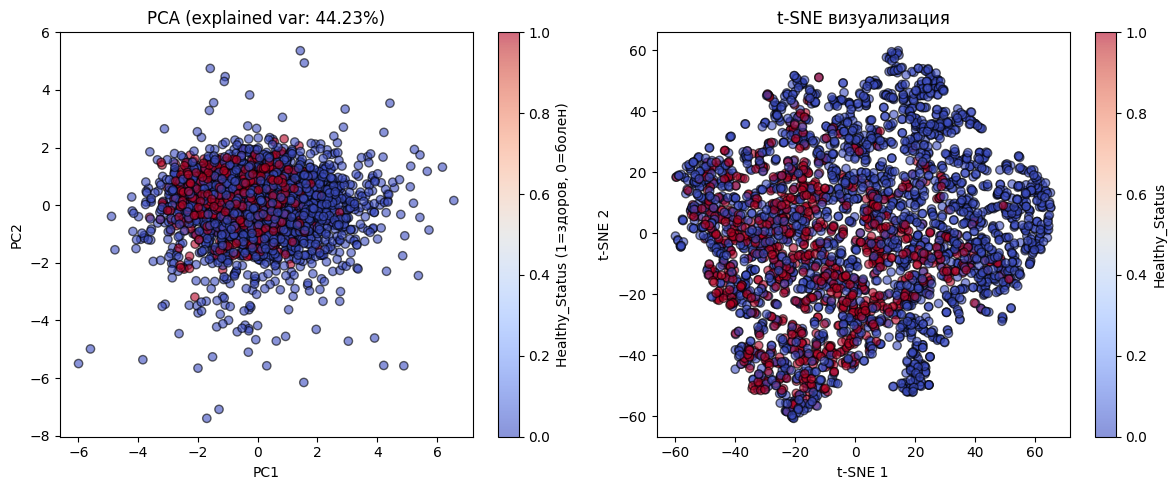

In [13]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6, edgecolors='k')
plt.colorbar(scatter, label='Healthy_Status (1=здоров, 0=болен)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'PCA (explained var: {pca.explained_variance_ratio_.sum():.2%})')

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', alpha=0.6, edgecolors='k')
plt.colorbar(scatter, label='Healthy_Status')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE визуализация')
plt.tight_layout()
plt.show()

## 5. AutoML с FLAML

In [14]:
from flaml.automl.automl import AutoML

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

settings = {
    "time_budget": 120,              
    "metric": 'f1',             
    "task": 'classification',
    "estimator_list": ['lgbm', 'rf', 'xgboost', 'catboost'],
    "log_file_name": 'flaml_ecg.log',
    "seed": 42,
    "verbose": 3
}

automl = AutoML()
automl.fit(X_train=X_train, y_train=y_train, **settings)

Train size: 2413, Test size: 1035
[flaml.automl.logger: 04-29 17:05:36] {2375} INFO - task = classification
[flaml.automl.logger: 04-29 17:05:36] {2386} INFO - Evaluation method: cv


[flaml.automl.logger: 04-29 17:05:36] {2489} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 04-29 17:05:36] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'catboost']
[flaml.automl.logger: 04-29 17:05:36] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-29 17:05:36] {3046} INFO - Estimated sufficient time budget=417s. Estimated necessary time budget=1s.
[flaml.automl.logger: 04-29 17:05:36] {3097} INFO -  at 0.1s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 04-29 17:05:36] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-29 17:05:36] {3097} INFO -  at 0.1s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 04-29 17:05:36] {2911} INFO - iteration 2, current learner lgbm
[flaml.automl.logger: 04-29 17:05:36] {3097} INFO -  at 0.1s,	estimator lgbm's best error=1.0000e+00,	best estimator

## 6. Оценка модели

F1-метрика на тестовой выборке: 0.6341

Classification report:
              precision    recall  f1-score   support

   Болен (0)       0.87      0.82      0.85       747
  Здоров (1)       0.60      0.68      0.63       288

    accuracy                           0.78      1035
   macro avg       0.73      0.75      0.74      1035
weighted avg       0.79      0.78      0.79      1035



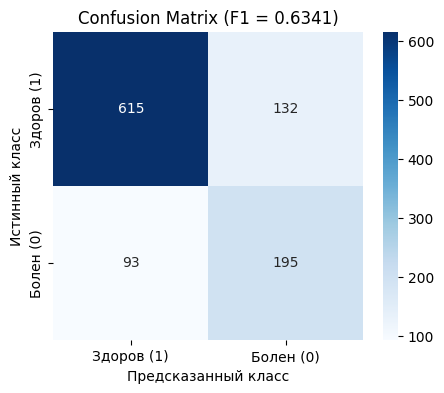

In [15]:
y_pred = automl.predict(X_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-метрика на тестовой выборке: {f1:.4f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=['Болен (0)', 'Здоров (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Здоров (1)', 'Болен (0)'],
            yticklabels=['Здоров (1)', 'Болен (0)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Confusion Matrix (F1 = {f1:.4f})')
plt.show()

## 7. Анализ лучшей модели

In [16]:
print("Лучшая найденная модель:", automl.best_estimator)
print("Лучшие гиперпараметры:", automl.best_config)

Лучшая найденная модель: xgboost
Лучшие гиперпараметры: {'n_estimators': 4, 'max_leaves': 4, 'min_child_weight': np.float64(0.0023739628979470148), 'learning_rate': np.float64(0.6766840569205814), 'subsample': np.float64(0.9925218760781988), 'colsample_bylevel': np.float64(0.8084608072764494), 'colsample_bytree': np.float64(0.6649662749624623), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(0.16159648522172318)}


C:\Users\user\AppData\Local\Temp\ipykernel_10264\2266508890.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


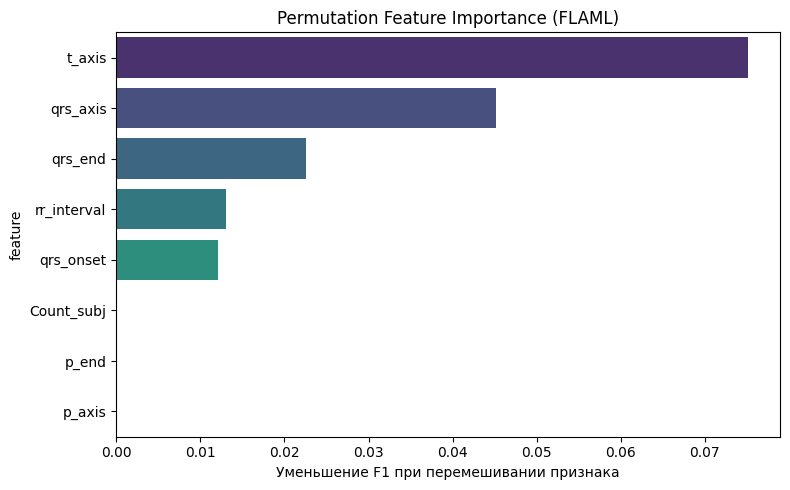

In [17]:
from sklearn.inspection import permutation_importance

best_model = automl.model.estimator

perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Permutation Feature Importance (FLAML)')
plt.xlabel('Уменьшение F1 при перемешивании признака')
plt.tight_layout()
plt.show()

## 9. Выводы

- После очистки данных от аномалий (значения 29999 и др.) осталось **X** строк.
- Визуализация PCA/t-SNE показала разделимость классов.
- FLAML за **120 секунд** подобрал модель **{best_model}**.
- Достигнуто значение **F1 = {f1:.4f}**, что говорит о хорошем качестве бинарной классификации.
- Наиболее важными признаками оказались **{importance_df.iloc[0]['feature']}** и **{importance_df.iloc[1]['feature']}**.